没有学到,可能是因为相关数据的斜率没有见过,从而给予了因子更小的权重,面对新的情况,预测表现不好.  
比“单个变量有没有超范围”更值得研究的是这三层
- 数值陌生：训练金价最高 3000，测试出现 4000。
- 组合陌生：金价、铜价、利率各自都没超范围，但“高金价＋低铜价＋高利率”的组合以前很少出现。
- 对应关系改变：类似的金铜价格组合，过去对应一种股价水平，现在因为产量、成本或估值变化，对应另一种水平。

# 06：模型学习到的依据是什么？

区分三件事：价格水平越界、近期涨幅陌生、模型对金铜的响应关系改变。沿用05最后的7→16→32→1、ReLU、Adam、学习率0.01、全批量固定100轮；以MAPE评价，同日输入对应原Dataset中的目标，不在此改成未来收益率预测。

四组主实验：A原变量，B原变量＋日期，C原变量＋金铜5/20条记录涨幅，D原变量＋日期＋涨幅；另加T仅日期作趋势参照。所有组统一删除前20条记录，因此A/B与05不是完全相同训练样本。窗口按数据记录计数，不假定等于完整市场交易日。日期不提供历史记忆，C/D才显式输入近期变化。

测试年2021—2026，每年只用此前数据训练。包含2022的结果完整保留，并单列排除2022的条件汇总；排除测试年不会删除后续训练集中的2022数据。种子42/7/123用于检查初始化敏感性，不把种子当成独立市场样本。测试年份已被查看，属于探索性诊断。

In [1]:
from pathlib import Path
import hashlib, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from IPython.display import display

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()), Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
# 检验副本可通过环境变量指定输出目录；平时运行写入项目results。
import os
OUT = Path(os.environ.get('MLP06_OUT', str(ROOT/'results/mlp_basis_06')))
OUT.mkdir(parents=True, exist_ok=True)
YEARS, SEEDS = list(range(2021, 2027)), [42, 7, 123]
EPOCHS, LR = 100, .01
torch.set_num_threads(1)
d = pd.read_pickle(ROOT/'src/pickle/Dataset.pkl')
raw, target = d['X'].copy(), d['Y'].copy()
assert raw.index.equals(target.index) and raw.shape[1] == 7
assert isinstance(raw.index, pd.DatetimeIndex) and raw.index.is_unique and raw.index.is_monotonic_increasing
assert np.isfinite(raw.to_numpy()).all() and np.isfinite(np.asarray(target)).all()
y = pd.Series(np.asarray(target).reshape(-1), index=raw.index, name='Actual')
assert (y > 0).all(), 'MAPE要求目标为正'
metals = ['Gold Futures Price', 'Copper Futures Price']
assert (raw[metals] > 0).all().all()
f = raw.copy()
f['elapsed_days'] = (f.index.normalize()-f.index.min().normalize()).days+1
returns = []
for metal in metals:
    for k in [5, 20]:
        name = f'{metal}_return_{k}'
        f[name] = raw[metal].div(raw[metal].shift(k)).sub(1)
        returns.append(name)
f = f.dropna()
y = y.loc[f.index]
BASE = list(raw.columns)
GROUPS = {'A_base': BASE, 'B_time': BASE+['elapsed_days'],
          'C_returns': BASE+returns, 'D_both': BASE+['elapsed_days']+returns,
          'T_time_only': ['elapsed_days']}
assert np.isfinite(f.to_numpy()).all()
display(pd.DataFrame({'Model':GROUPS.keys(), 'Inputs':[len(v) for v in GROUPS.values()]}))
print('数据截止：', f.index.max(), '统一样本数：',len(f))
(OUT/'config.json').write_text(json.dumps({'years':YEARS,'seeds':SEEDS,'epochs':EPOCHS,'lr':LR,'groups':GROUPS,
    'dataset_sha256':hashlib.sha256((ROOT/'src/pickle/Dataset.pkl').read_bytes()).hexdigest()},ensure_ascii=False,indent=2))

数据截止： 2026-07-23 00:00:00 统一样本数： 3817
Out[1]: 1357


,Model,Inputs
0,A_base,7
1,B_time,8
2,C_returns,11
3,D_both,12
4,T_time_only,1


## 1. 相同样本上的对照训练
标准化仅拟合当年训练段；不裁剪越界输入。每组独立初始化，相同种子并不代表不同输入维度的初始权重相同。训练目标保持MSE，评价用MAPE与有符号平均百分比误差MPE（正值高估）。

In [2]:
def tensor(a): return torch.tensor(np.asarray(a), dtype=torch.float32)
def fit_model(cols, idx, seed):
    sx = StandardScaler().fit(f.loc[idx, cols])
    sy = StandardScaler().fit(y.loc[idx].to_numpy().reshape(-1,1))
    x = tensor(sx.transform(f.loc[idx,cols]))
    z = tensor(sy.transform(y.loc[idx].to_numpy().reshape(-1,1)))
    torch.manual_seed(seed)
    model = nn.Sequential(nn.Linear(len(cols),16), nn.ReLU(), nn.Linear(16,32), nn.ReLU(), nn.Linear(32,1))
    opt = torch.optim.Adam(model.parameters(),lr=LR)
    history = []
    for _ in range(EPOCHS):
        opt.zero_grad()
        loss = ((model(x)-z)**2).mean()
        assert torch.isfinite(loss)
        loss.backward(); opt.step()
        history.append(loss.item())
    model.eval()
    return model, sx, sy, history

metrics, predictions, gradients, ranges, splits = [], [], [], [], []
for year in YEARS:
    tr = f.index[f.index.year < year]
    te = f.index[f.index.year == year]
    assert len(tr)>0 and len(te)>1 and tr.max()<te.min()
    for split, idx in [('Train',tr),('Test',te)]:
        splits.append(dict(Year=year, Split=split,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())))
    for col in f.columns:
        a,b=f.loc[tr,col],f.loc[te,col]
        scale=a.std(ddof=0)
        ranges.append(dict(Year=year,Feature=col,Outside_percent=100*((b<a.min())|(b>a.max())).mean(),
            Max_excess_std=max(0,b.max()-a.max(),a.min()-b.min())/scale if scale>0 else np.nan))
    for seed in SEEDS:
        for name,cols in GROUPS.items():
            model,sx,sy,history = fit_model(cols,tr,seed)
            for split,idx in [('Train',tr),('Test',te)]:
                with torch.no_grad():
                    pred=sy.inverse_transform(model(tensor(sx.transform(f.loc[idx,cols]))).numpy()).ravel()
                truth=y.loc[idx].to_numpy()
                assert np.isfinite(pred).all()
                pe=100*(pred-truth)/truth
                metrics.append(dict(Year=year,Seed=seed,Model=name,Split=split,N=len(idx),MAPE=np.abs(pe).mean(),MPE=pe.mean()))
                predictions.append(pd.DataFrame({'Date':idx,'Year':year,'Seed':seed,'Model':name,'Split':split,'Actual':truth,'Predicted':pred,'APE':np.abs(pe)}))
                # 局部偏导：其他输入固定，原始输入单位下的模型响应。
                if seed==42 and name in ['A_base','B_time']:
                    xx=tensor(sx.transform(f.loc[idx,cols])).requires_grad_(True)
                    gg=torch.autograd.grad(model(xx).sum(),xx)[0].detach().numpy()
                    gg=gg*sy.scale_[0]/sx.scale_
                    for col in metals:
                        j=cols.index(col)
                        gradients.append(pd.DataFrame({'Date':idx,'Year':year,'Split':split,'Model':name,'Feature':col,
                            'dy_dx':gg[:,j], 'Response_per_1pct_input':gg[:,j]*f.loc[idx,col].to_numpy()*.01}))
            if year==2026 and seed==42:
                torch.save({'state_dict':model.state_dict(),'features':cols,'sx_mean':sx.mean_.tolist(),'sx_scale':sx.scale_.tolist(),
                    'sy_mean':sy.mean_.tolist(),'sy_scale':sy.scale_.tolist(),'loss':history},OUT/f'{name}_2026_seed42.pt')
    print(f'{year}完成', flush=True)
metrics=pd.DataFrame(metrics)
predictions=pd.concat(predictions,ignore_index=True)
gradients=pd.concat(gradients,ignore_index=True)
ranges=pd.DataFrame(ranges)
for name,frame in [('metrics',metrics),('predictions',predictions),('gradients',gradients),('feature_ranges',ranges),('splits',pd.DataFrame(splits))]:
    frame.to_csv(OUT/f'{name}.csv',index=False)
display(pd.DataFrame(splits))

2021完成
2022完成
2023完成
2024完成
2025完成
2026完成


,Year,Split,N,Start,End
0,2021,Train,2305,2012-06-06,2020-12-31
1,2021,Test,272,2021-01-01,2021-12-31
2,2022,Train,2577,2012-06-06,2021-12-31
3,2022,Test,274,2022-01-03,2022-12-31
4,2023,Train,2851,2012-06-06,2022-12-31
5,2023,Test,273,2023-01-02,2023-12-31
6,2024,Train,3124,2012-06-06,2023-12-31
7,2024,Test,273,2024-01-01,2024-12-31
8,2025,Train,3397,2012-06-06,2024-12-31
9,2025,Test,268,2025-01-01,2025-12-31


## 2. 按年比较与成对差异
先在每年内平均三个种子的MAPE，再对年份等权平均。成对差异为前者减后者，负数表示改善。标准差只反映种子波动，不是统计显著性。

Model,A_base,B_time,C_returns,D_both,T_time_only
Year,,,,,
2021,10.583,7.476,6.273,8.285,15.649
2022,32.531,36.850,30.116,40.321,42.572
2023,15.822,11.264,12.977,14.330,5.858
2024,7.349,9.660,8.688,9.038,15.912
2025,17.070,16.855,17.868,17.018,17.003
2026,9.215,8.980,7.361,8.262,26.764


mean     std
Year Model                      
2021 A_base       10.583   6.998
     B_time        7.476   1.461
     C_returns     6.273   0.655
     D_both        8.285   2.985
     T_time_only  15.649   3.081
2022 A_base       32.531  12.711
     B_time       36.850   5.152
     C_returns    30.116   8.148
     D_both       40.321   2.731
     T_time_only  42.572  10.853
2023 A_base       15.822   4.127
     B_time       11.264   0.158
     C_returns    12.977   1.946
     D_both       14.330   2.973
     T_time_only   5.858   1.934
2024 A_base        7.349   0.434
     B_time        9.660   2.513
     C_returns     8.688   1.518
     D_both        9.038   1.404
     T_time_only  15.912   3.074
2025 A_base       17.070   1.490
     B_time       16.855   1.334
     C_returns    17.868   1.050
     D_both       17.018   0.779
     T_time_only  17.003   1.896
2026 A_base        9.215   1.966
     B_time        8.980   2.786
     C_returns     7.361   1.253
     D_both        8.262   2.019
     T_time_only  26.764   5.111

Model,A_base,B_time,C_returns,D_both,T_time_only
All_years,15.428,15.181,13.880,16.209,20.626
Exclude_2022,12.008,10.847,10.633,11.387,16.237


B_minus_A         C_minus_A         D_minus_B        D_minus_C       
          mean     std      mean     std      mean    std      mean    std
Year                                                                      
2021    -3.107   8.397    -4.310   7.569     0.808  2.815     2.012  3.343
2022     4.319  17.663    -2.415  14.361     3.471  2.423    10.205  9.688
2023    -4.558   3.985    -2.845   3.984     3.066  3.076     1.353  4.523
2024     2.311   2.942     1.339   1.932    -0.622  1.266     0.350  0.303
2025    -0.215   1.373     0.798   2.522     0.163  2.113    -0.850  0.771
2026    -0.234   2.839    -1.854   3.198    -0.718  2.349     0.901  3.176

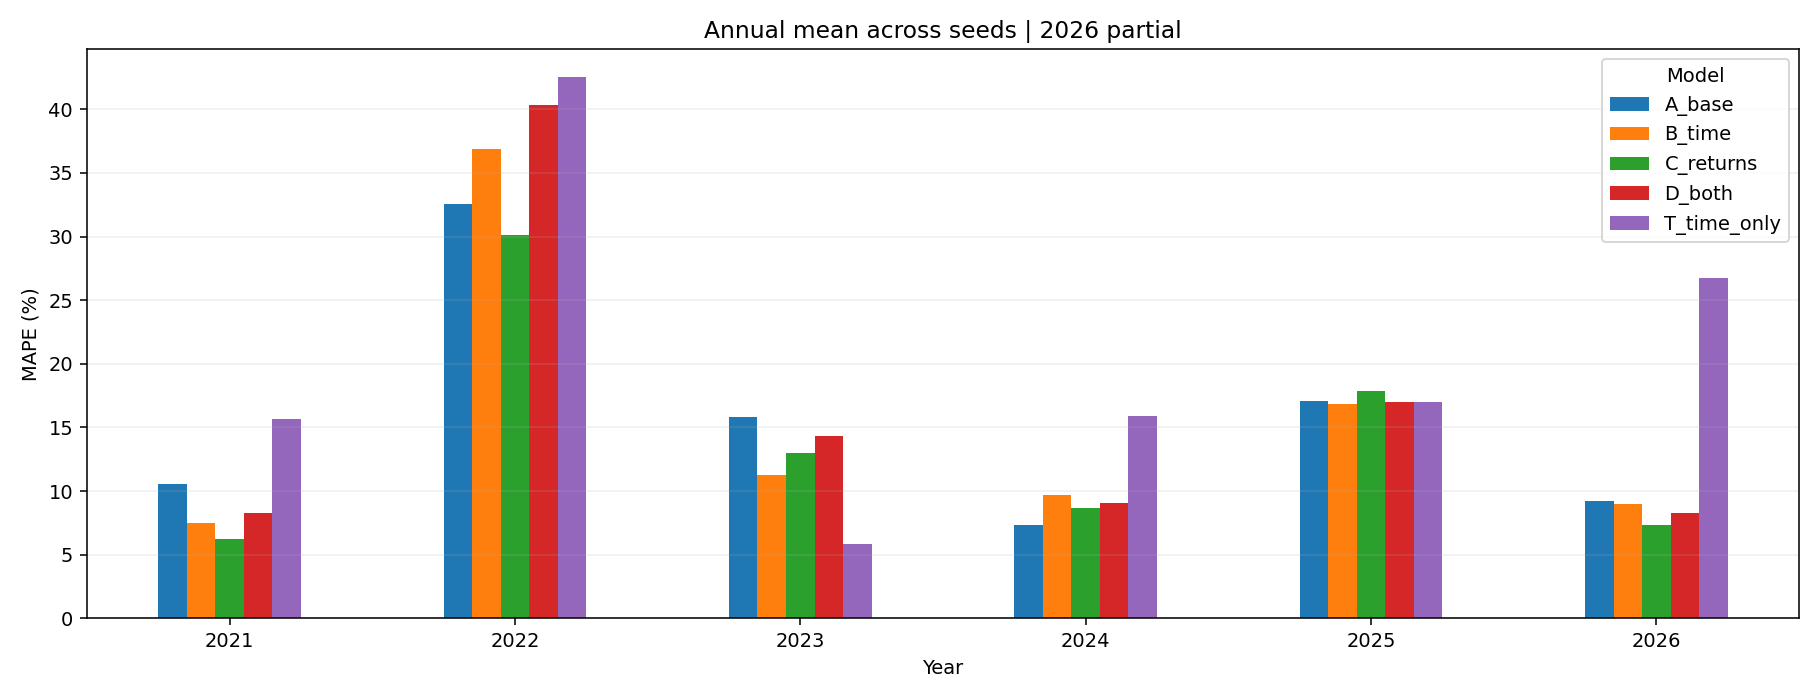

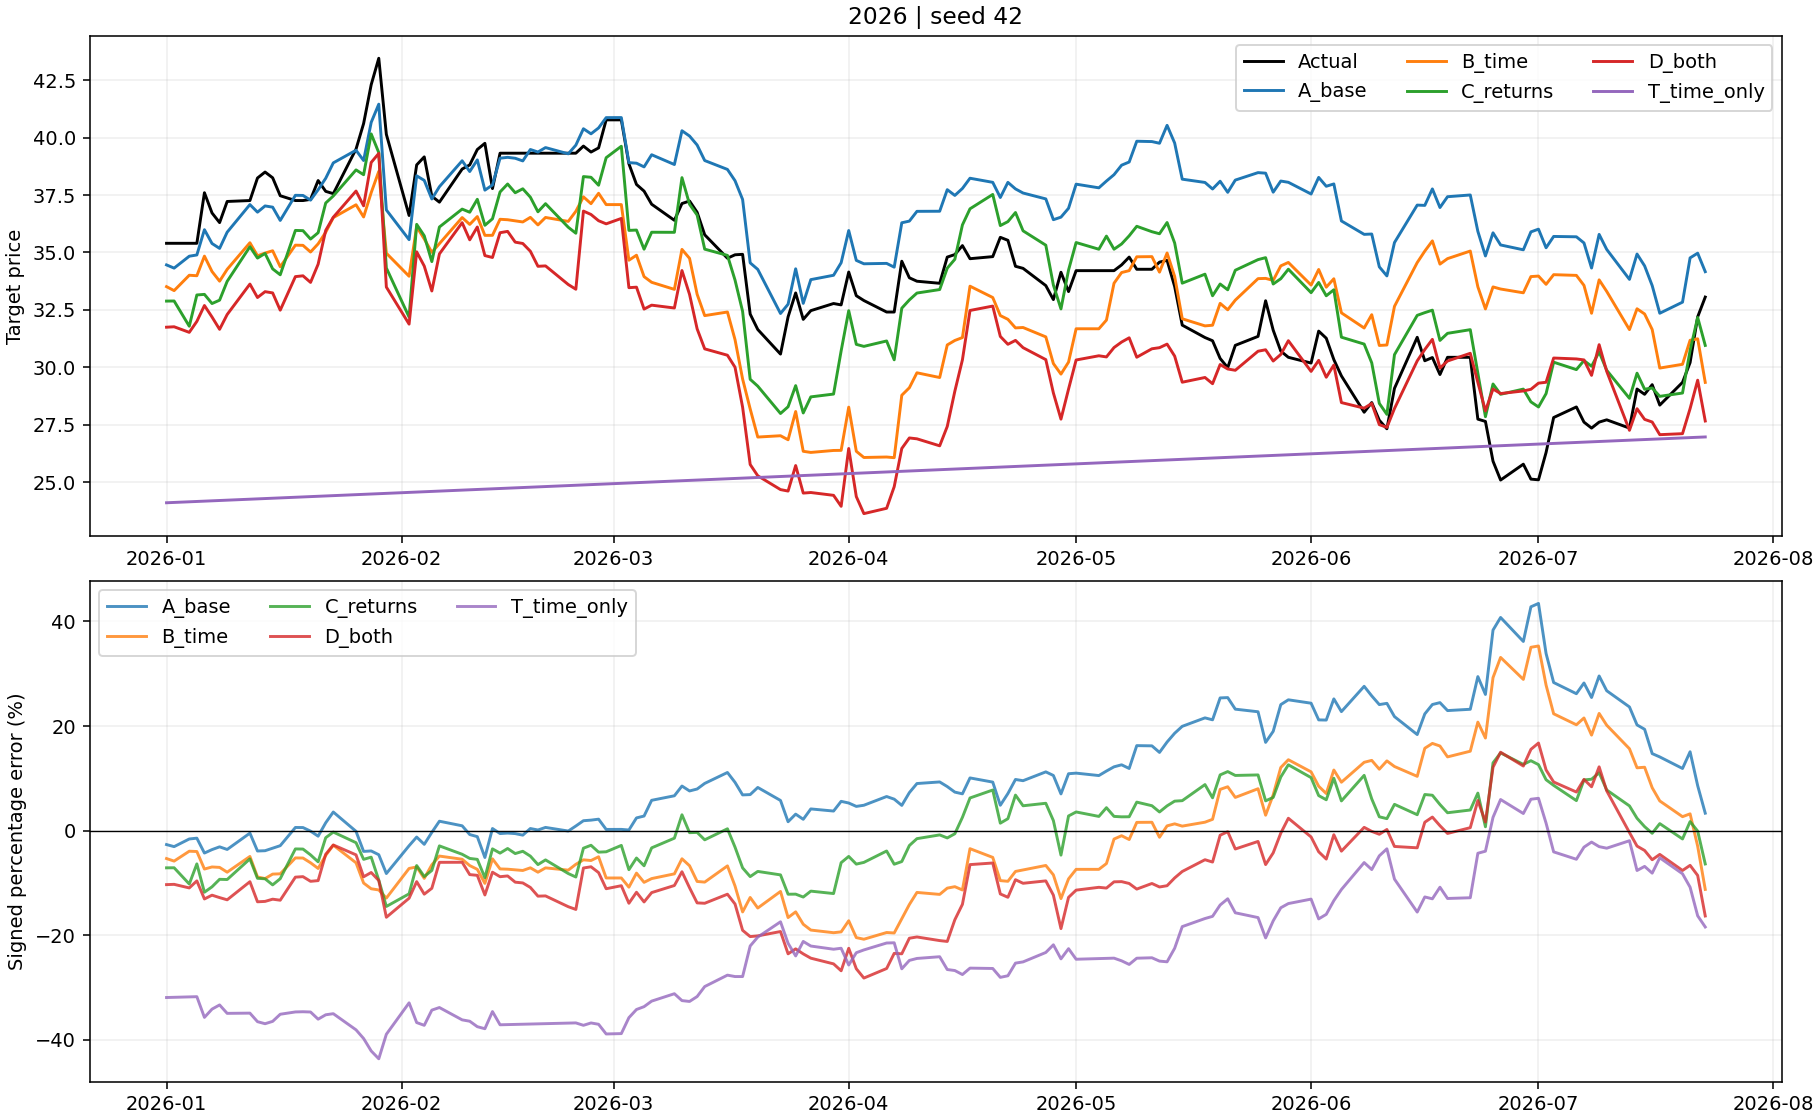

In [3]:
test=metrics[metrics.Split=='Test']
annual=test.groupby(['Year','Model']).MAPE.mean().unstack()
display(annual.round(3))
display(test.groupby(['Year','Model']).MAPE.agg(['mean','std']).round(3))
summary=pd.DataFrame({'All_years':annual.mean(),'Exclude_2022':annual.drop(index=2022,errors='ignore').mean()}).T
display(summary.round(3))
pair=test.pivot(index=['Year','Seed'],columns='Model',values='MAPE')
contrasts=pd.DataFrame({'B_minus_A':pair.B_time-pair.A_base,'C_minus_A':pair.C_returns-pair.A_base,
    'D_minus_B':pair.D_both-pair.B_time,'D_minus_C':pair.D_both-pair.C_returns})
display(contrasts.groupby('Year').agg(['mean','std']).round(3))
annual.to_csv(OUT/'annual_mape.csv');summary.to_csv(OUT/'summary_mape.csv');contrasts.to_csv(OUT/'paired_differences.csv')
ax=annual.plot.bar(figsize=(13,5),rot=0)
ax.set(ylabel='MAPE (%)',title='Annual mean across seeds | 2026 partial')
ax.grid(axis='y',alpha=.2)
plt.tight_layout();plt.savefig(OUT/'annual_mape.png',dpi=140);plt.show()
# 主图固定seed42，不根据测试结果挑选最佳种子。
frame=predictions.query("Year==2026 and Seed==42 and Split=='Test'")
fig,axes=plt.subplots(2,1,figsize=(13,8),constrained_layout=True)
a=frame[frame.Model=='A_base'];axes[0].plot(a.Date,a.Actual,label='Actual',color='black')
for name,g in frame.groupby('Model'):
    axes[0].plot(g.Date,g.Predicted,label=name)
    axes[1].plot(g.Date,100*(g.Predicted-g.Actual)/g.Actual,label=name,alpha=.8)
axes[0].set(title='2026 | seed 42',ylabel='Target price');axes[1].set(ylabel='Signed percentage error (%)')
axes[1].axhline(0,color='black',lw=.7)
for ax in axes: ax.legend(ncol=3);ax.grid(alpha=.2)
plt.savefig(OUT/'2026_predictions.png',dpi=140);plt.show()

## 3. 价格越界与涨幅越界分别检查
即使各列都没有越界，也可能是陌生的联合组合。这张表只描述单变量范围，不直接证明误差原因。

In [4]:
display(ranges[ranges.Feature.isin(metals+returns)].pivot(index='Feature',columns='Year',values='Outside_percent').round(2))
display(ranges[ranges.Feature.isin(metals+returns)].pivot(index='Feature',columns='Year',values='Max_excess_std').round(2))

Year,2021,2022,2023,2024,2025,2026
Feature,,,,,,
Copper Futures Price,86.4,2.55,0.00,1.10,22.39,73.03
Copper Futures Price_return_20,0.0,2.92,0.00,0.00,1.12,0.00
Copper Futures Price_return_5,0.0,0.00,0.00,0.00,3.36,0.00
Gold Futures Price,0.0,0.00,2.93,82.78,92.54,61.84
Gold Futures Price_return_20,0.0,0.00,0.00,0.00,0.00,2.63
Gold Futures Price_return_5,0.0,0.00,0.00,0.00,0.00,0.00


Year,2021,2022,2023,2024,2025,2026
Feature,,,,,,
Copper Futures Price,2.17,0.30,0.00,0.25,1.04,1.04
Copper Futures Price_return_20,0.00,0.66,0.00,0.00,0.13,0.00
Copper Futures Price_return_5,0.00,0.00,0.00,0.00,3.95,0.00
Gold Futures Price,0.00,0.00,0.12,2.51,4.73,1.28
Gold Futures Price_return_20,0.00,0.00,0.00,0.00,0.00,0.61
Gold Futures Price_return_5,0.00,0.00,0.00,0.00,0.00,0.00


从这里看出,24,25,26三年金价越界最多,但是平均预测的准确率相对22年的30-40%的MAPE,只有16%以内.因此,学习到参数,与因子越界关系不大.  
从金铜价格增长比例来看,几乎不存在越界问题.22年前的股票价格没有出现涨幅的越界,照样预测不准.  
25年来看,出现了金价与铜价的涨幅的越界幅度较大,但是25,26年的预测准确率确实更好,因此,也不能说是百分比越界造成了模型预测准确率不好.

## 4. 模型对金铜的响应斜率
以下是A/B对输入的局部偏导，不是金铜价格沿时间的上涨速度，也不是真实市场的因果效应。`Response_per_1pct_input`是局部导数乘当前输入的1%，表示一阶近似的预测股价变化；跨ReLU边界时不能当作精确1%扰动结果。只比较原始特征模型，避免“改价格却保持派生涨幅固定”的解释冲突。

金铜和时间可能高度相关，因此偏导不能独立识别真实经济机制。

dy_dx  ... Response_per_1pct_input
                                      mean  ...                  median
Split Model  Feature                        ...                        
Test  A_base Copper Futures Price  2.11415  ...                 0.12718
             Gold Futures Price    0.01020  ...                 0.29502
      B_time Copper Futures Price  2.35455  ...                 0.14853
             Gold Futures Price    0.00689  ...                 0.19673
Train A_base Copper Futures Price  1.50936  ...                 0.03328
             Gold Futures Price    0.00404  ...                 0.02398
      B_time Copper Futures Price  1.31323  ...                 0.03564
             Gold Futures Price    0.00290  ...                 0.00905

[8 rows x 4 columns]

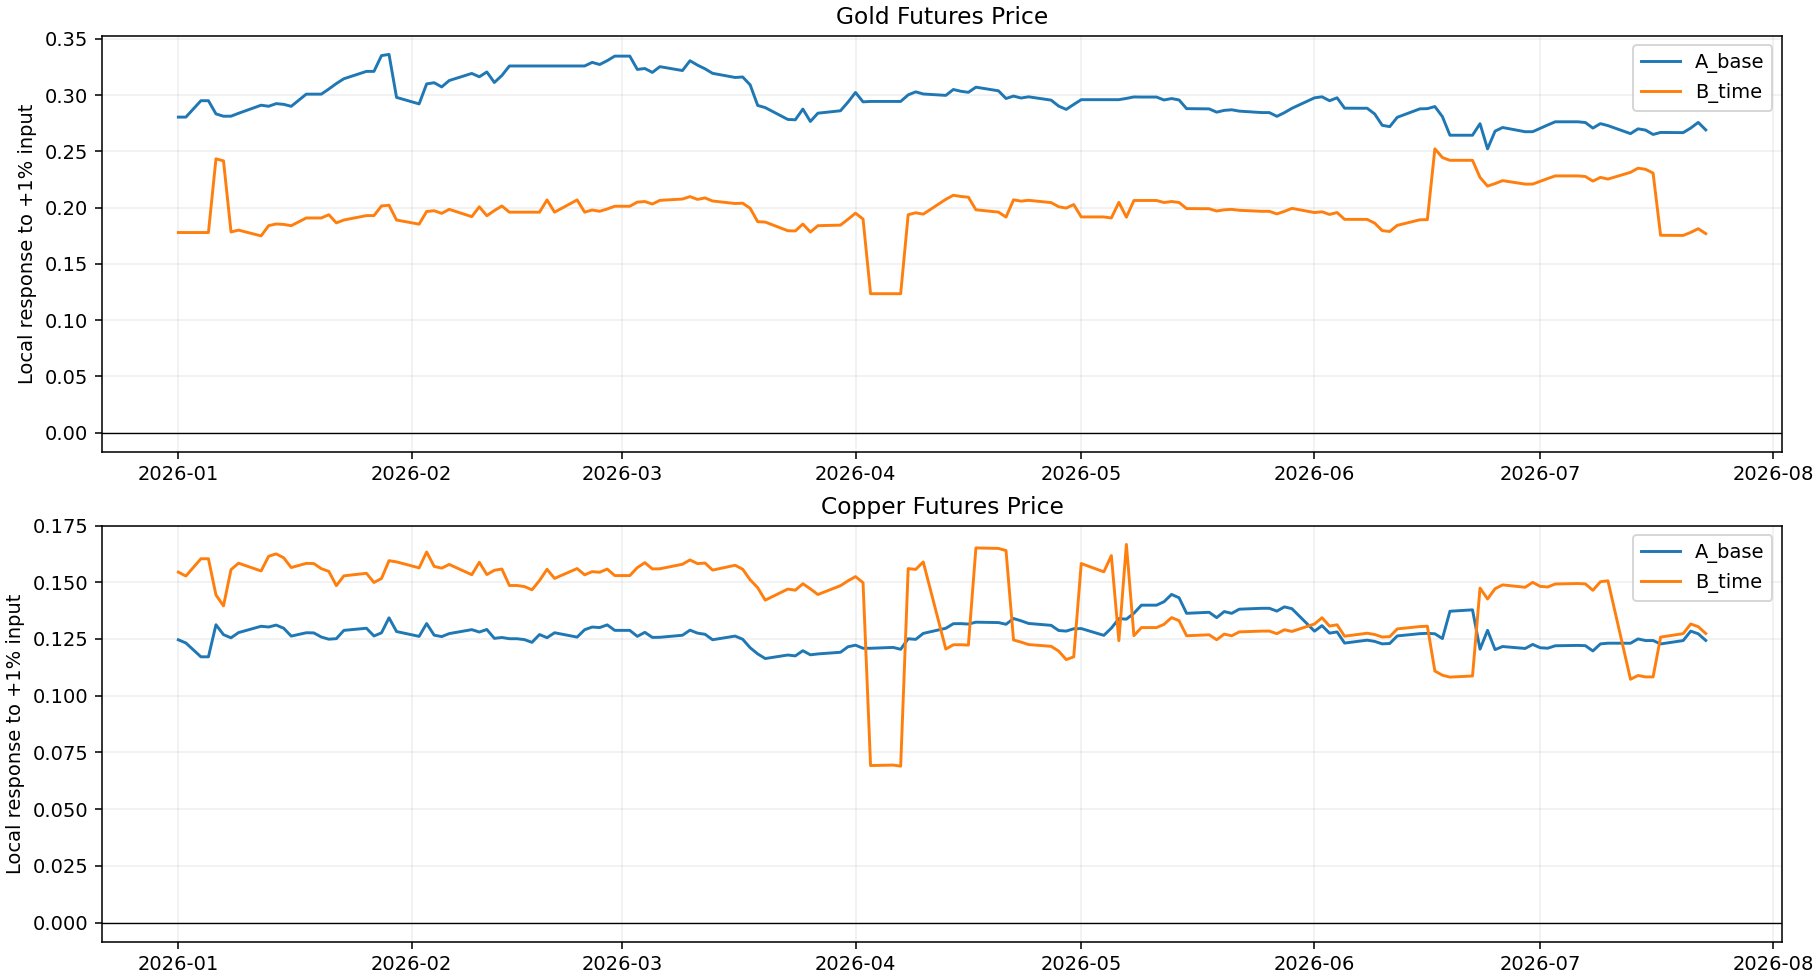

In [5]:
g=gradients[gradients.Year==2026]
display(g.groupby(['Split','Model','Feature'])[['dy_dx','Response_per_1pct_input']].agg(['mean','median']).round(5))
fig,axes=plt.subplots(2,1,figsize=(13,7),constrained_layout=True)
for ax,metal in zip(axes,metals):
    for name in ['A_base','B_time']:
        z=g[(g.Feature==metal)&(g.Model==name)&(g.Split=='Test')]
        ax.plot(z.Date,z.Response_per_1pct_input,label=name)
    ax.axhline(0,color='black',lw=.7);ax.set(title=metal,ylabel='Local response to +1% input');ax.legend();ax.grid(alpha=.2)
plt.savefig(OUT/'2026_response_slopes.png',dpi=140);plt.show()

从响应斜率可以看出,带有时间的模型,它的响应开关更多,斜率跳变明显.可能是对于不同状况下,启用不同的斜率.适用于不同的情况,对整体预测的情况是否有改善,目前还不确定.

## 如何解释结果

- C相对A、D相对B在多个年度及种子改善：支持“近期涨幅有额外预测信息”，并不证明之前所有误差由涨幅陌生引起。
- B改善而C不改善：不支持仅用“缺少近期涨幅”解释时间特征的帮助。
- T仅时间已接近B：提示总体时间趋势值得进一步检验，不能由此认定宏观变量没有价值。
- A/B斜率不同：说明加入时间改变了拟合响应，但无法证明哪组斜率更符合真实机制。
- MPE用于区分整体高估/低估，MAPE用于衡量偏离大小；不使用测试期真实值事后校准模型再当作可实现预测。

本实验固定100轮以延续05，并非证明每组都充分收敛。涨幅组增加了输入与参数，结果含容量和优化差异。下一步若要比较泛化能力，应在新的向前验证段内选训练轮数，并留出未用于选择的未来数据。

## 本次运行观察

2026年三个种子的平均MAPE：A原变量9.2146%，B加时间8.9803%，C加涨幅7.3609%，D两者8.2620%，T仅时间26.7644%。涨幅在本期提供了有用信息，但不能证明旧模型“没学过”的就是涨幅。

排除2022后的五年等权MAPE：A 12.0077%，B 10.8473%，C 10.6334%，D 11.3866%。D没有优于B，说明两类信息未呈现稳定叠加收益；包含2022的六年均值分别为15.4283%、15.1811%、13.8805%、16.2090%。结果只覆盖2021—2026，与05的2015—2026汇总范围不同。前20条样本统一删除，且使用三个种子，数值不应直接当成05单种子结果的复现。

T在2026明显较差，不支持“仅凭时间就能达到宏观变量模型表现”；这仍不识别时间特征代理的真实因素。响应斜率表与图提供模型内部诊断，不作因果解释。

---

从模型观察到,近年的表现,平均来说与基准模型相比,加入了时间T表现确实更好一点.在排除22年的表现后则改善明显.  
但是我们又怀疑模型没有学到金铜价格的涨幅,AI选择了5日与20日的金铜价格涨幅变化.近年来,无论是否剔除22年,加入金价相对变化率的效果都是更好的.因为不删除22年,其可解释性也更强.此外,模型D加入了时间与金铜相对涨幅,表现更差,应该放弃.

如果我们把激活函数换成Sigmoid,就不会出现响应斜率调变得现象了.之后值得换一下激活函数再试一次.

---

## 总结  
### 我们在这轮对比实验中,放弃了继续保留时间维度,而是选择金铜价格的变化率.22年单独删除没有道理,且无论是否删除,表现仍然没有金铜价格的相对变化率表现好.